In [1]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import neurokit2 as nk
import spikeinterface.extractors as se
import matplotlib.pyplot as plt
import h5py
import glob
import glob
import os
import os
import h5py
import numpy as np
from scipy.signal import butter, filtfilt, resample_poly
from scipy.signal import find_peaks
import neurokit2 as nk

In [2]:
H5_DIRS = {
    "day1": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs", #update to your paths
    "day2": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\h5_outputs",
}

In [3]:
def load_clean_resp_signal_ecu(h5_file, target_rate=100, fs=20000):
    """
    Loads, filters, downsamples respiration from ECU-style .h5.
    Preserves original preprocessing logic.
    
    Returns:
        rsp_cleaned : np.ndarray
        time_vector : np.ndarray
        fs_out      : float (target_rate)
        metadata    : dict
    """

    try:
        with h5py.File(h5_file, 'r') as f:

            # -----------------------------
            # Load respiration (ECU Ain1)
            # -----------------------------
            analog_keys = list(f['analog'].keys())
            resp_keys = [k for k in analog_keys if "Ain1" in k]
            if len(resp_keys) == 0:
                raise RuntimeError("No ECU Ain1 channel found")

            resp_key = resp_keys[0]
            resp = f['analog'][resp_key][()]['voltage'].astype(float)

            # -----------------------------
            # Metadata (keep for compatibility)
            # -----------------------------
            metadata = {
                "fs_original": fs,
                "source": "ECU_Ain1",
                "file": os.path.basename(h5_file)
            }

    except Exception as e:
        print(f" Error loading {os.path.basename(h5_file)}: {e}")
        return None, None, None, None

    # -----------------------------
    # PRE-CLEAN (CRITICAL)
    # -----------------------------
    # Remove NaNs / infs
    bad = ~np.isfinite(resp)
    if np.any(bad):
        resp[bad] = np.nanmedian(resp)

    # Remove DC offset
    resp = resp - np.median(resp)

    # Clip extreme artifacts (opto / motion)
    mad = np.median(np.abs(resp))
    if mad > 0:
        resp = np.clip(resp, -10 * mad, 10 * mad)

    # -----------------------------
    # Low-pass before downsampling
    # -----------------------------
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # -----------------------------
    # Downsample
    # -----------------------------
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # -----------------------------
    # Bandpass (NeuroKit)
    # -----------------------------
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # -----------------------------
    # Time vector
    # -----------------------------
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate, metadata

In [4]:
def get_sniff_respiratory_rate(
    signal,
    time,
    sniff_start,
    sniff_end,
    sampling_rate=100,
    max_rate_hz=12
):
    """
    Compute average respiration/sniff rate using inter-breath intervals (IBI).
    
    Returns:
        avg_rate_hz (float) or np.nan
    """

    # -----------------------------
    # Mask window
    # -----------------------------
    sniff_mask = (time >= sniff_start) & (time < sniff_end)

    if sniff_mask.sum() < sampling_rate:  # <1 s of data
        return np.nan

    signal_sniff = signal[sniff_mask]
    time_sniff = time[sniff_mask]

    # -----------------------------
    # Pre-clean for peak detection
    # -----------------------------
    signal_sniff = signal_sniff - np.mean(signal_sniff)

    # -----------------------------
    # Peak detection
    # -----------------------------
    min_ibi = 1.0 / max_rate_hz
    min_distance = int(min_ibi * sampling_rate)

    peaks, _ = find_peaks(
        signal_sniff,
        distance=min_distance
    )

    if len(peaks) < 2:
        return np.nan

    # -----------------------------
    # IBI and rate
    # -----------------------------
    peak_times = time_sniff[peaks]
    ibi = np.diff(peak_times)          # seconds
    inst_rate = 1.0 / ibi              # Hz

    return np.mean(inst_rate)


In [5]:
import h5py

h5_file = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs\1_1_RI1_f1_d_on_20260111_164638.h5"

with h5py.File(h5_file, "r") as f:
    print("DIO keys:", f["dio"].keys())



DIO keys: <KeysViewHDF5 ['1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Din1', '1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Dout1']>


In [6]:
with h5py.File(h5_file, "r") as f:
    for k in f["dio"].keys():
        dset = f["dio"][k]
        print("\nDIO key:", k)
        print("Type:", type(dset))
        print("Dtype:", dset.dtype)
        print("Dtype names:", dset.dtype.names)
        print("Shape:", dset.shape)




DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Din1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (6547,)

DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Dout1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (1,)


In [7]:
with h5py.File(h5_file, "r") as f:
    for k in f["dio"].keys():
        dset = f["dio"][k]
        print("\nDIO key:", k)
        print("Type:", type(dset))
        print("Dtype:", dset.dtype)
        print("Dtype names:", dset.dtype.names)
        print("Shape:", dset.shape)




DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Din1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (6547,)

DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Dout1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (1,)


In [8]:
with h5py.File(h5_file, "r") as f:
    for k in f["dio"].keys():
        dset = f["dio"][k]
        print("\nDIO key:", k)
        print("Type:", type(dset))
        print("Dtype:", dset.dtype)
        print("Dtype names:", dset.dtype.names)
        print("Shape:", dset.shape)




DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Din1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (6547,)

DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Dout1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (1,)


In [9]:
with h5py.File(h5_file, "r") as f:
    print("Time group keys:", f["time"].keys())



Time group keys: <KeysViewHDF5 ['1_1_RI1_f1_d_on_20260111_164638.timestamps']>


In [10]:
def extract_laser_ttl_times_ecu(h5_file, trodes_rate=20000):
    """
    Extract rising-edge laser TTL pulse times (seconds)
    from ECU_Din1 using Trodes clock ticks (20 kHz).
    """
    import h5py
    import numpy as np

    with h5py.File(h5_file, "r") as f:
        # Find ECU_Din1 (laser pulses)
        dio_keys = [k for k in f["dio"].keys() if "ECU_Din1" in k]
        if len(dio_keys) == 0:
            return np.array([])

        dio = f["dio"][dio_keys[0]][()]
        dio_ticks = dio["time"].astype(float)   # Trodes ticks
        dio_states = dio["state"].astype(int)   # 0 / 1

    # Rising edges (0 → 1)
    rising_edges = np.where(np.diff(dio_states) == 1)[0]

    # Convert ticks → seconds
    pulse_times_sec = dio_ticks[rising_edges] / trodes_rate

    return pulse_times_sec


In [11]:
with h5py.File(h5_file, "r") as f:
    time_key = list(f["time"].keys())[0]
    global_time = f["time"][time_key][()]

print(global_time.dtype.names)



('time', 'systime')


In [12]:
pulse_times = extract_laser_ttl_times_ecu(h5_file)

print("Total pulses:", len(pulse_times))
print("First pulse (s):", pulse_times[0])
print("Last pulse (s):", pulse_times[-1])

print("Baseline pulses:", np.sum(pulse_times < 60))
print("RI pulses:", np.sum((pulse_times >= 60) & (pulse_times <= 240)))


Total pulses: 3273
First pulse (s): 321.66025
Last pulse (s): 564.12595
Baseline pulses: 0
RI pulses: 0


In [13]:
def load_resp_simple(h5_file, target_rate=100, trodes_rate=20000):
    import h5py
    import numpy as np
    from scipy.signal import butter, filtfilt, resample_poly
    import neurokit2 as nk

    with h5py.File(h5_file, 'r') as f:
        resp_key = [k for k in f['analog'].keys() if "Ain1" in k][0]
        resp = f['analog'][resp_key][()]['voltage'].astype(float)

    # Time relative to recording start
    t = np.arange(len(resp)) / trodes_rate

    # Clean
    resp -= np.median(resp)
    mad = np.median(np.abs(resp))
    if mad > 0:
        resp = np.clip(resp, -10 * mad, 10 * mad)

    # Low-pass + downsample
    nyq = trodes_rate / 2
    b, a = butter(4, (target_rate / 2) / nyq, btype="low")
    resp_filt = filtfilt(b, a, resp)

    down = int(trodes_rate // target_rate)
    resp_ds = resample_poly(resp_filt, up=1, down=down)
    t_ds = t[::down]

    # Bandpass
    resp_clean = nk.signal_filter(
        resp_ds,
        lowcut=0.1,
        highcut=20,
        sampling_rate=target_rate,
        order=2
    )

    return resp_clean, t_ds


In [14]:
SOCIAL_START = 60
SOCIAL_END   = 240


In [15]:
rsp, t = load_resp_simple(h5_file)

social_rate = get_sniff_respiratory_rate(
    signal=rsp,
    time=t,
    sniff_start=SOCIAL_START,
    sniff_end=SOCIAL_END,
    sampling_rate=100
)

print("Social respiration rate (Hz):", social_rate)


Social respiration rate (Hz): 9.152318103834027


In [17]:
rows = []

for day, h5_dir in H5_DIRS.items():
    h5_files = glob.glob(os.path.join(h5_dir, "*.h5"))

    for h5_file in h5_files:
        rsp, t = load_resp_simple(h5_file)

        social_rate = get_sniff_respiratory_rate(
            signal=rsp,
            time=t,
            sniff_start=60,
            sniff_end=240,
            sampling_rate=100
        )

        rows.append({
            "File": os.path.basename(h5_file),
            "SocialRespRate": social_rate,
        })

df = pd.DataFrame(rows)


In [ ]:
df["Laser"] = df["File"].str.contains("_on_").map(
    {True: "ON", False: "OFF"}
)

# Extract cage number (first number before "_")
df["Cage"] = df["File"].str.extract(r"^(\d+)").astype(int)

# Assign virus by cage parity
df["Virus"] = df["Cage"].apply(
    lambda x: "ChR" if x % 2 == 1 else "GFP"
)


df["Subject"] = df["File"].str.extract(r"(\d_\d)")


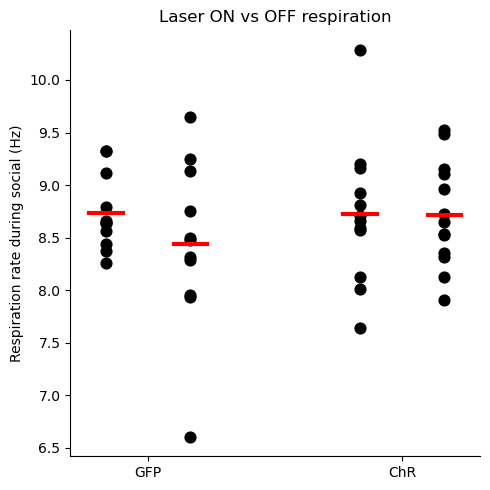

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))

for i, virus in enumerate(["GFP", "ChR"]):
    sub = df[df["Virus"] == virus]

    for j, laser in enumerate(["OFF", "ON"]):
        vals = sub[sub["Laser"] == laser]["SocialRespRate"]

        x = i*3 + j
        ax.scatter(
            np.ones(len(vals))*x,
            vals,
            color="black",
            s=60
        )
        ax.plot(
            [x-0.2, x+0.2],
            [vals.mean(), vals.mean()],
            lw=3,
            color="red"
        )

ax.set_xticks([0.5, 3.5])
ax.set_xticklabels(["GFP", "ChR"])
ax.set_ylabel("Respiration rate during social (Hz)")
ax.set_title("Laser ON vs OFF respiration")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


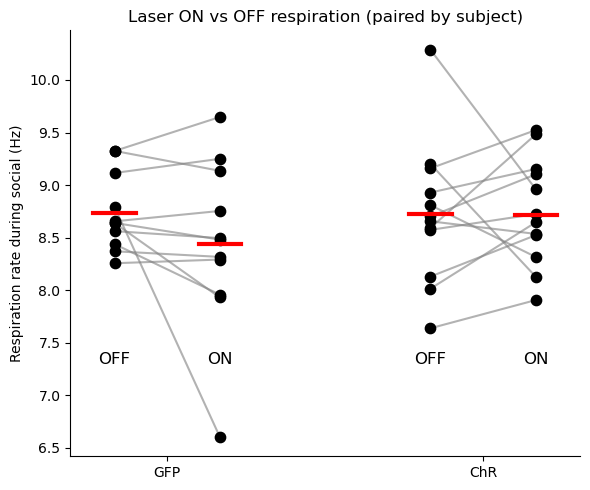

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))

# x positions
xpos = {
    ("GFP", "OFF"): 0,
    ("GFP", "ON"):  1,
    ("ChR", "OFF"): 3,
    ("ChR", "ON"):  4,
}

for virus in ["GFP", "ChR"]:
    df_v = df[df["Virus"] == virus]

    for subject in df_v["Subject"].unique():
        sub_df = df_v[df_v["Subject"] == subject]

        # ensure we have both ON and OFF
        if set(sub_df["Laser"]) != {"ON", "OFF"}:
            continue

        off_val = sub_df[sub_df["Laser"] == "OFF"]["SocialRespRate"].values[0]
        on_val  = sub_df[sub_df["Laser"] == "ON"]["SocialRespRate"].values[0]

        x = [xpos[(virus, "OFF")], xpos[(virus, "ON")]]
        y = [off_val, on_val]

        ax.plot(x, y, color="gray", alpha=0.6, zorder=1)
        ax.scatter(x, y, color="black", s=55, zorder=2)

# Mean bars
for (virus, laser), x in xpos.items():
    vals = df[(df["Virus"] == virus) & (df["Laser"] == laser)]["SocialRespRate"]
    ax.plot(
        [x - 0.2, x + 0.2],
        [vals.mean(), vals.mean()],
        color="red",
        lw=3,
        zorder=3
    )

# Formatting
ax.set_xticks([0.5, 3.5])
ax.set_xticklabels(["GFP", "ChR"])
ax.set_ylabel("Respiration rate during social (Hz)")
ax.set_title("Laser ON vs OFF respiration (paired by subject)")

# ON/OFF labels
ax.text(0, 7.3, "OFF", ha="center", fontsize=12)
ax.text(1, 7.3, "ON",  ha="center", fontsize=12)
ax.text(3, 7.3, "OFF", ha="center", fontsize=12)
ax.text(4, 7.3, "ON",  ha="center", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
df.head


<bound method NDFrame.head of                                    File  SocialRespRate Laser  Cage Virus  \
0    1_1_RI1_f1_d_on_20260111_164638.h5        9.152318    ON     1   ChR   
1   1_2_RI1_f2_f_off_20260109_165330.h5       10.288113   OFF     1   ChR   
2   1_3_RI1_f1_c_off_20260110_130254.h5        8.591796   OFF     1   ChR   
3    2_1_RI1_f2_h_on_20260110_145355.h5        9.249470    ON     2   GFP   
4   2_2_RI1_f1_b_off_20260109_150435.h5        8.654789   OFF     2   GFP   
5    2_3_RI1_f2_f_on_20260110_132734.h5        8.291091    ON     2   GFP   
6    3_1_RI1_f1_b_on_20260111_154618.h5        9.101620    ON     3   ChR   
7   3_2_RI1_f1_a_off_20260114_161949.h5        8.129087   OFF     3   ChR   
8    3_3_RI1_f1_c_on_20260111_162426.h5        7.905516    ON     3   ChR   
9    4_1_RI1_f2_h_on_20260111_161337.h5        6.603175    ON     4   GFP   
10  4_2_RI1_f1_c_off_20260110_150626.h5        8.639576   OFF     4   GFP   
11   4_3_RI1_f2_e_on_20260111_152801.h5       

In [ ]:
import glob

mp4_path = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\9_1_RI1_m2_m_on_20260111_165857.rec\9_1_RI1_m2_m_on_20260111_165857.1.mp4"


mp4s = glob.glob(REC_DIR + r"\*.mp4")
mp4s


NameError: name 'REC_DIR' is not defined

In [ ]:
mp4_path_off = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\1_1_RI1_f2_e_off_20260110_154830.rec\1_1_RI1_f2_e_off_20260110_154830.1.mp4"


mp4_path = mp4_path_off


In [ ]:
import os
os.path.exists(mp4_path)


True

In [ ]:
h5_file = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs\9_1_RI1_m2_m_on_20260111_165857.h5"
h5_off = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\h5_outputs\1_1_RI1_f2_e_off_20260110_154830.h5"


Text(0, 0.5, 'Respiration')

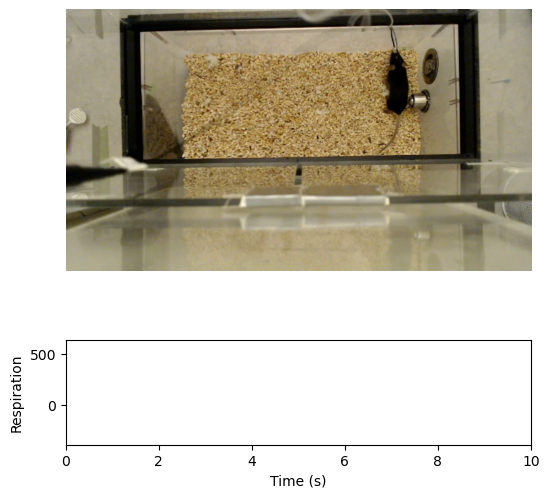

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ---- Load video ----
cap = cv2.VideoCapture(mp4_path)
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# ---- Respiration ----
rsp, t = load_resp_simple(h5_file)

# ---- Figure layout ----
fig, (ax_vid, ax_rsp) = plt.subplots(
    2, 1, figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# First frame
ret, frame = cap.read()
im = ax_vid.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax_vid.axis("off")

# Respiration plot
line, = ax_rsp.plot([], [], color="black", lw=1)
ax_rsp.set_ylim(np.percentile(rsp, 1), np.percentile(rsp, 99))
ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")

WINDOW = 10  # seconds shown in trace

def update(frame_idx):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if not ret:
        return im, line

    # Update video
    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Current video time
    current_time = frame_idx / fps

    # Respiration up to now
    mask = t <= current_time

    line.set_data(t[mask], rsp[mask])
    ax_rsp.set_xlim(0, max(10, current_time))

    return im, line


ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False
)
ax_rsp.set_ylim(np.percentile(rsp, 1), np.percentile(rsp, 99))
ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")


Saved respiration_with_video.mp4


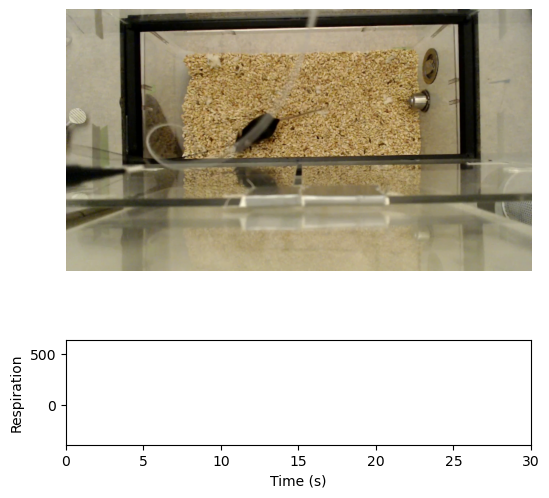

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter

# ---------- Load video ----------
cap = cv2.VideoCapture(mp4_path)
fps = cap.get(cv2.CAP_PROP_FPS)

# Render only first 30 seconds
MAX_SECONDS = 30
n_frames = int(MAX_SECONDS * fps)

# ---------- Load respiration ----------
rsp, t = load_resp_simple(h5_file)

# ---------- Figure ----------
fig, (ax_vid, ax_rsp) = plt.subplots(
    2, 1, figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# Read first frame ONCE
ret, frame = cap.read()
im = ax_vid.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax_vid.axis("off")

# Resp axis
line, = ax_rsp.plot([], [], color="black", lw=1)
ax_rsp.set_ylim(np.percentile(rsp, 1), np.percentile(rsp, 99))
ax_rsp.set_xlim(0, MAX_SECONDS)
ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")

# ---------- Update function ----------
def update(frame_idx):
    ret, frame = cap.read()
    if not ret:
        return im, line

    # Update video
    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Current time
    current_time = frame_idx / fps

    # Respiration up to now
    mask = t <= current_time
    line.set_data(t[mask], rsp[mask])

    return im, line

# ---------- Animation ----------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False
)

# ---------- Save ----------
writer = FFMpegWriter(fps=fps, bitrate=1200)

ani.save(
    "respiration_with_video.mp4",
    writer=writer,
    dpi=120
)

print("Saved respiration_with_video.mp4")



In [ ]:
import os
print(os.getcwd())


c:\Users\sjs93\OneDrive\Documents\respiratory_pilot


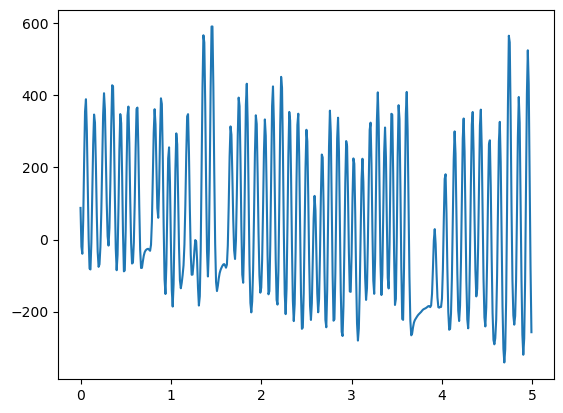

In [ ]:
plt.figure()
plt.plot(t[:500], rsp[:500])
plt.show()


Saved respiration_with_video.mp4


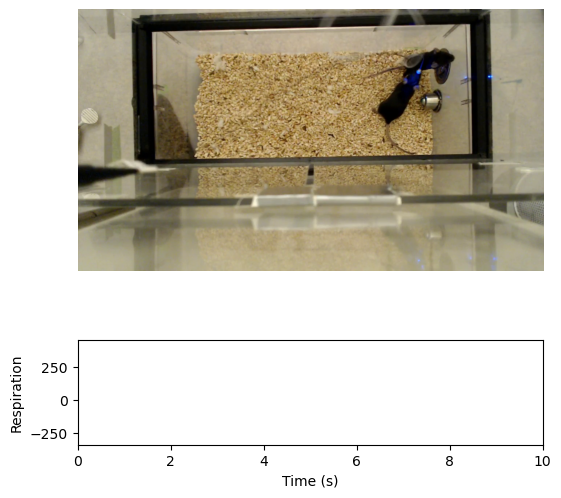

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter

# ==============================
# Parameters (EDIT THESE)
# ==============================
START_TIME = 70.0      # seconds into recording
WINDOW_SEC = 10.0      # duration to display (seconds)
OUTFILE = "respiration_with_video.mp4"

# ==============================
# Load video
# ==============================
cap = cv2.VideoCapture(mp4_path)
fps = cap.get(cv2.CAP_PROP_FPS)

# Jump to desired start time ONCE
start_frame = int(START_TIME * fps)
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

n_frames = int(WINDOW_SEC * fps)

# ==============================
# Load respiration
# ==============================
rsp, t = load_resp_simple(h5_file)

# Keep only respiration after START_TIME and re-zero time
mask_start = t >= START_TIME
rsp_seg = rsp[mask_start]
t_seg = t[mask_start] - START_TIME

# Keep only the window we will display
mask_win = t_seg <= WINDOW_SEC
rsp_seg = rsp_seg[mask_win]
t_seg = t_seg[mask_win]

# ==============================
# Figure
# ==============================
fig, (ax_vid, ax_rsp) = plt.subplots(
    2, 1, figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- Video axis ---
ret, frame = cap.read()
im = ax_vid.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax_vid.axis("off")

# --- Respiration axis ---
line, = ax_rsp.plot([], [], color="black", lw=1)
ax_rsp.set_xlim(0, WINDOW_SEC)
ax_rsp.set_ylim(
    np.percentile(rsp_seg, 1),
    np.percentile(rsp_seg, 99)
)
ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")

# ==============================
# Update function
# ==============================
def update(frame_idx):
    ret, frame = cap.read()
    if not ret:
        return im, line

    # Update video frame
    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Current time relative to START_TIME
    current_time = frame_idx / fps

    # Update respiration trace
    mask = t_seg <= current_time
    line.set_data(t_seg[mask], rsp_seg[mask])

    return im, line

# ==============================
# Animation
# ==============================
ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False
)

# ==============================
# Save movie
# ==============================
writer = FFMpegWriter(fps=fps, bitrate=1200)

ani.save(
    OUTFILE,
    writer=writer,
    dpi=120
)

print(f"Saved {OUTFILE}")


Video FPS: 15.003987240829346
Starting at 70.0s (frame 1050)
Rendering 10.0s (150 frames)
Saved movie to: 1_1_RI1_f2_e_off_20260110_154830.1_resp_demo.mp4


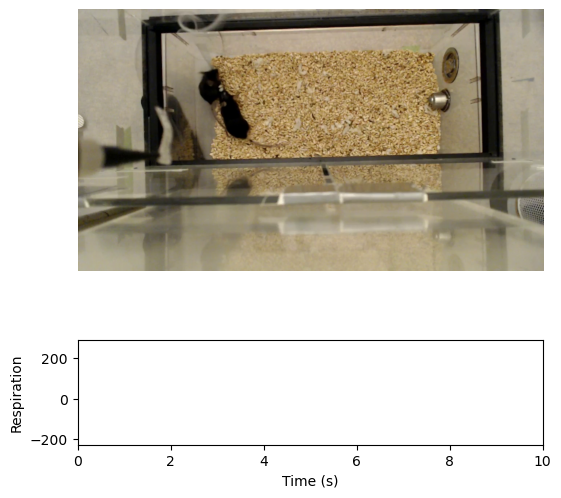

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
import os

# =====================================================
# USER PARAMETERS — ONLY EDIT THESE
# =====================================================

# Path to MP4 (inside .rec folder)
mp4_path = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\1_1_RI1_f2_e_off_20260110_154830.rec\1_1_RI1_f2_e_off_20260110_154830.1.mp4"

# Path to matching H5 file
h5_file = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\h5_outputs\1_1_RI1_f2_e_off_20260110_154830.h5"

# When to start the clip (seconds into recording)
START_TIME = 70.0

# How much time to show (seconds)
WINDOW_SEC = 10.0

# Output movie name
OUTFILE = os.path.basename(mp4_path).replace(".mp4", "_resp_demo.mp4")

# =====================================================
# LOAD VIDEO
# =====================================================

cap = cv2.VideoCapture(mp4_path)
fps = cap.get(cv2.CAP_PROP_FPS)

# Jump to start time ONCE (important for speed)
start_frame = int(START_TIME * fps)
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

# Number of frames to render
n_frames = int(WINDOW_SEC * fps)

print(f"Video FPS: {fps}")
print(f"Starting at {START_TIME}s (frame {start_frame})")
print(f"Rendering {WINDOW_SEC}s ({n_frames} frames)", flush=True)

# =====================================================
# LOAD RESPIRATION
# =====================================================

rsp, t = load_resp_simple(h5_file)

# Keep respiration after START_TIME and re-zero time
mask_start = t >= START_TIME
rsp_seg = rsp[mask_start]
t_seg = t[mask_start] - START_TIME

# Keep only the window we will display
mask_win = t_seg <= WINDOW_SEC
rsp_seg = rsp_seg[mask_win]
t_seg = t_seg[mask_win]

# =====================================================
# SET UP FIGURE
# =====================================================

fig, (ax_vid, ax_rsp) = plt.subplots(
    2, 1,
    figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# ---- Video axis ----
ret, frame = cap.read()
im = ax_vid.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax_vid.axis("off")

# ---- Respiration axis ----
line, = ax_rsp.plot([], [], color="black", lw=1)

ax_rsp.set_xlim(0, WINDOW_SEC)
ax_rsp.set_ylim(
    np.percentile(rsp_seg, 1),
    np.percentile(rsp_seg, 99)
)

ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")

# =====================================================
# UPDATE FUNCTION
# =====================================================

def update(frame_idx):
    ret, frame = cap.read()
    if not ret:
        return im, line

    # Update video
    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Current time relative to START_TIME
    current_time = frame_idx / fps

    # Update respiration trace
    mask = t_seg <= current_time
    line.set_data(t_seg[mask], rsp_seg[mask])

    return im, line

# =====================================================
# CREATE ANIMATION
# =====================================================

ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False
)

# =====================================================
# SAVE MOVIE
# =====================================================

writer = FFMpegWriter(fps=fps, bitrate=1200)

ani.save(
    OUTFILE,
    writer=writer,
    dpi=120
)

print(f"Saved movie to: {OUTFILE}", flush=True)


In [ ]:
mp4_path = r"E:\Aim1\AIM1\Day1_new\RI1_s1_1_p5_2_nRB6_20250622_143958.rec\RI1_s1_1_p5_2_nRB6_20250622_143958.1.mp4"
h5_file = r"E:\Aim1\AIM1\Day1_new\h5_outputs\RI1_s1_1_p5_2_nRB6_20250622_143958.h5"


In [ ]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

[INFO] Cohort 1 (NO VIRUS)
[INFO] Video FPS: 13.001397999784922
[INFO] Starting at 10.0s (frame 130)
[INFO] Rendering 10.0s (130 frames)
[DONE] Saved movie to: RI1_s1_1_p5_2_nRB6_20250622_143958.1_resp_demo_cohort1.mp4


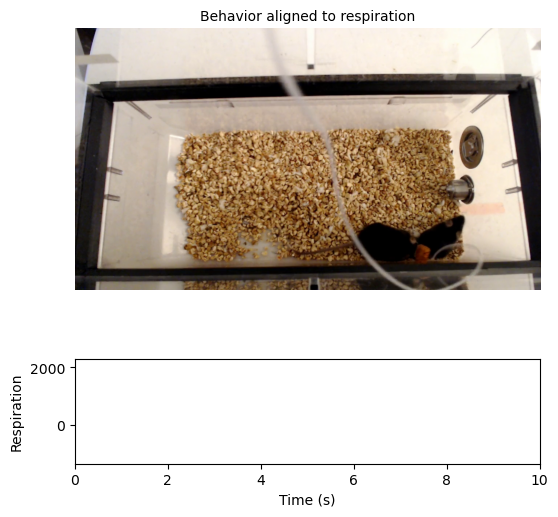

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
import os

# =====================================================
# SESSION INFO (DOCUMENTATION ONLY)
# =====================================================
# Cohort: 1
# Virus: NONE
# Respiration source: merged H5, cleaned via load_clean_resp_signal
# Purpose: visualize respiration aligned to behavior video
# =====================================================

# =====================================================
# USER PARAMETERS — EDIT THESE ONLY
# =====================================================

# Path to MP4 (inside .rec folder)
mp4_path = r"E:\Aim1\AIM1\Day1_new\RI1_s1_1_p5_2_nRB6_20250622_143958.rec\RI1_s1_1_p5_2_nRB6_20250622_143958.1.mp4"

# Path to matching merged respiration H5
h5_file = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"

# Start time for visualization (seconds into recording)
START_TIME = 10.0

# Duration to display (seconds)
WINDOW_SEC = 10.0

# Output movie name
OUTFILE = os.path.basename(mp4_path).replace(".mp4", "_resp_demo_cohort1.mp4")

# =====================================================
# LOAD VIDEO
# =====================================================

cap = cv2.VideoCapture(mp4_path)
fps = cap.get(cv2.CAP_PROP_FPS)

start_frame = int(START_TIME * fps)
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

n_frames = int(WINDOW_SEC * fps)

print("[INFO] Cohort 1 (NO VIRUS)")
print(f"[INFO] Video FPS: {fps}")
print(f"[INFO] Starting at {START_TIME}s (frame {start_frame})")
print(f"[INFO] Rendering {WINDOW_SEC}s ({n_frames} frames)", flush=True)

# =====================================================
# LOAD RESPIRATION (CLEANED + DOWNSAMPLED)
# =====================================================

rsp, t, fs = load_clean_resp_signal(h5_file)

# Keep respiration after START_TIME and re-zero time
mask_start = t >= START_TIME
rsp_seg = rsp[mask_start]
t_seg = t[mask_start] - START_TIME

# Keep only the window to be displayed
mask_win = t_seg <= WINDOW_SEC
rsp_seg = rsp_seg[mask_win]
t_seg = t_seg[mask_win]

# =====================================================
# SET UP FIGURE
# =====================================================

fig, (ax_vid, ax_rsp) = plt.subplots(
    2, 1,
    figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# ---- Video axis ----
ret, frame = cap.read()
im = ax_vid.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax_vid.axis("off")
ax_vid.set_title("Behavior aligned to respiration", fontsize=10)

# ---- Respiration axis ----
line, = ax_rsp.plot([], [], color="black", lw=1)

ax_rsp.set_xlim(0, WINDOW_SEC)
ax_rsp.set_ylim(
    np.percentile(rsp_seg, 1),
    np.percentile(rsp_seg, 99)
)

ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")

# =====================================================
# UPDATE FUNCTION
# =====================================================

def update(frame_idx):
    ret, frame = cap.read()
    if not ret:
        return im, line

    # Update video frame
    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Current time relative to START_TIME
    current_time = frame_idx / fps

    # Update respiration trace
    mask = t_seg <= current_time
    line.set_data(t_seg[mask], rsp_seg[mask])

    return im, line

# =====================================================
# CREATE ANIMATION
# =====================================================

ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False
)

# =====================================================
# SAVE MOVIE
# =====================================================

writer = FFMpegWriter(fps=fps, bitrate=1200)

ani.save(
    OUTFILE,
    writer=writer,
    dpi=120
)

print(f"[DONE] Saved movie to: {OUTFILE}", flush=True)


[INFO] Cohort 1 (NO VIRUS)
[INFO] Video FPS: 13.001397999784922
[INFO] Starting at 10.0s (frame 130)
[INFO] Rendering 10.0s (130 frames)
[DONE] Saved movie to: RI1_s1_1_p5_2_nRB6_20250622_143958.1_resp_demo_cohort1.mp4


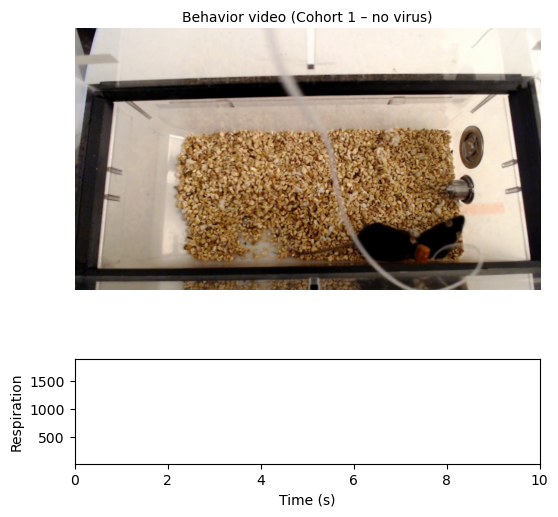

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
import os

# =====================================================
# SESSION INFO (DOCUMENTATION ONLY)
# =====================================================
# Cohort: 1
# Virus: NONE (no opsin, no control virus)
# Purpose: demo of respiration aligned to behavior video
# =====================================================

# =====================================================
# USER PARAMETERS — EDIT THESE ONLY
# =====================================================

# Path to MP4 (inside .rec folder)
mp4_path = r"E:\Aim1\AIM1\Day1_new\RI1_s1_1_p5_2_nRB6_20250622_143958.rec\RI1_s1_1_p5_2_nRB6_20250622_143958.1.mp4"

# Path to matching H5 file
h5_file = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"

# Start time for visualization (seconds into recording)
START_TIME = 10.0   # adjust if needed

# Duration to display (seconds)
WINDOW_SEC = 10.0

# Output movie name (auto-generated)
OUTFILE = os.path.basename(mp4_path).replace(".mp4", "_resp_demo_cohort1.mp4")

# =====================================================
# LOAD VIDEO
# =====================================================

cap = cv2.VideoCapture(mp4_path)
fps = cap.get(cv2.CAP_PROP_FPS)

start_frame = int(START_TIME * fps)
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

n_frames = int(WINDOW_SEC * fps)

print(f"[INFO] Cohort 1 (NO VIRUS)")
print(f"[INFO] Video FPS: {fps}")
print(f"[INFO] Starting at {START_TIME}s (frame {start_frame})")
print(f"[INFO] Rendering {WINDOW_SEC}s ({n_frames} frames)", flush=True)

# =====================================================
# LOAD RESPIRATION
# =====================================================

rsp, t = load_resp_cohort1(h5_file)

# Keep respiration after START_TIME and re-zero time
mask_start = t >= START_TIME
rsp_seg = rsp[mask_start]
t_seg = t[mask_start] - START_TIME

# Keep only the display window
mask_win = t_seg <= WINDOW_SEC
rsp_seg = rsp_seg[mask_win]
t_seg = t_seg[mask_win]

# =====================================================
# SET UP FIGURE
# =====================================================

fig, (ax_vid, ax_rsp) = plt.subplots(
    2, 1,
    figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# ---- Video axis ----
ret, frame = cap.read()
im = ax_vid.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax_vid.axis("off")
ax_vid.set_title("Behavior video (Cohort 1 – no virus)", fontsize=10)

# ---- Respiration axis ----
line, = ax_rsp.plot([], [], color="black", lw=1)

ax_rsp.set_xlim(0, WINDOW_SEC)
ax_rsp.set_ylim(
    np.percentile(rsp_seg, 1),
    np.percentile(rsp_seg, 99)
)

ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")

# =====================================================
# UPDATE FUNCTION
# =====================================================

def update(frame_idx):
    ret, frame = cap.read()
    if not ret:
        return im, line

    # Update video frame
    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Current time relative to START_TIME
    current_time = frame_idx / fps

    # Update respiration trace
    mask = t_seg <= current_time
    line.set_data(t_seg[mask], rsp_seg[mask])

    return im, line

# =====================================================
# CREATE ANIMATION
# =====================================================

ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False
)

# =====================================================
# SAVE MOVIE
# =====================================================

writer = FFMpegWriter(fps=fps, bitrate=1200)

ani.save(
    OUTFILE,
    writer=writer,
    dpi=120
)

print(f"[DONE] Saved movie to: {OUTFILE}", flush=True)


In [ ]:
import h5py
from IPython.display import display

with h5py.File(h5_file, "r") as f:
    display(list(f.keys()))



['ekg', 'ekg_metadata', 'metadata', 'resp', 'resp_metadata']